In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(url)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
print("Number of Records:", df.shape[0])
print("Number of Features:", df.shape[1])

print("Dataset Columns:")
print(df.columns)

Number of Records: 150
Number of Features: 5
Dataset Columns:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [4]:
print(df.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [5]:
print("Target Variable: species")
print(df["species"].unique())

Target Variable: species
['setosa' 'versicolor' 'virginica']


In [6]:
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [7]:
features = df.iloc[:, 0:4].values

print("Mean:")
print(np.mean(features, axis=0))

print("\nMinimum:")
print(np.min(features, axis=0))

print("\nMaximum:")
print(np.max(features, axis=0))

print("\nStandard Deviation:")
print(np.std(features, axis=0))

Mean:
[5.84333333 3.05733333 3.758      1.19933333]

Minimum:
[4.3 2.  1.  0.1]

Maximum:
[7.9 4.4 6.9 2.5]

Standard Deviation:
[0.82530129 0.43441097 1.75940407 0.75969263]


In [8]:
selected_data = df[["sepal_length", "petal_length", "species"]]

print(selected_data.head())

   sepal_length  petal_length species
0           5.1           1.4  setosa
1           4.9           1.4  setosa
2           4.7           1.3  setosa
3           4.6           1.5  setosa
4           5.0           1.4  setosa


In [9]:
filtered_data = df[df["petal_length"] > 4]

print(filtered_data.head())

    sepal_length  sepal_width  petal_length  petal_width     species
50           7.0          3.2           4.7          1.4  versicolor
51           6.4          3.2           4.5          1.5  versicolor
52           6.9          3.1           4.9          1.5  versicolor
54           6.5          2.8           4.6          1.5  versicolor
55           5.7          2.8           4.5          1.3  versicolor


In [10]:
grouped_data = df.groupby("species")

print(grouped_data.mean(numeric_only=True))

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


In [11]:
print(df.groupby("species").describe())

           sepal_length                                              \
                  count   mean       std  min    25%  50%  75%  max   
species                                                               
setosa             50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor         50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica          50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal_width         ... petal_length      petal_width         \
                 count   mean  ...          75%  max       count   mean   
species                        ...                                        
setosa            50.0  3.428  ...        1.575  1.9        50.0  0.246   
versicolor        50.0  2.770  ...        4.600  5.1        50.0  1.326   
virginica         50.0  2.974  ...        5.875  6.9        50.0  2.026   

                                               
                 std  min  25%  50%  75%  max  
species                   

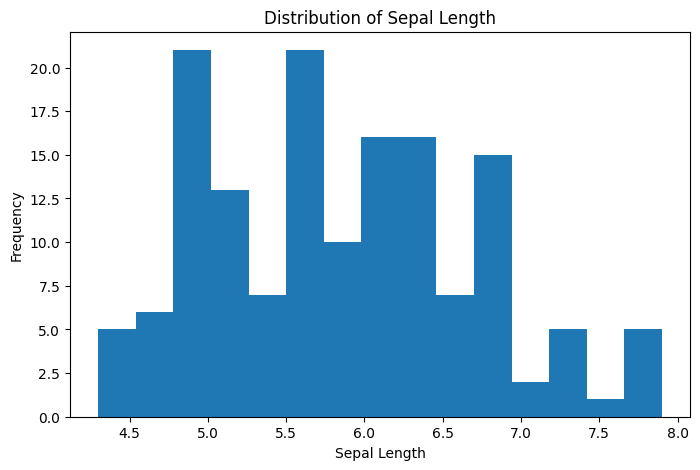

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df["sepal_length"], bins=15)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")

plt.show()

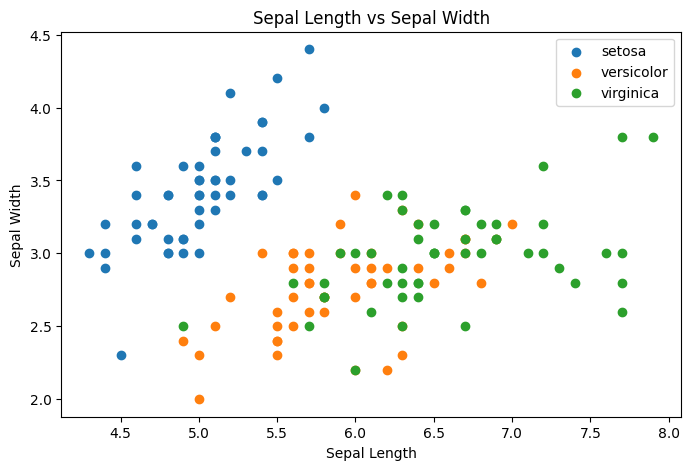

In [13]:
plt.figure(figsize=(8, 5))

for species in df["species"].unique():
    data = df[df["species"] == species]

    plt.scatter(
        data["sepal_length"],
        data["sepal_width"],
        label=species
    )

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

plt.show()

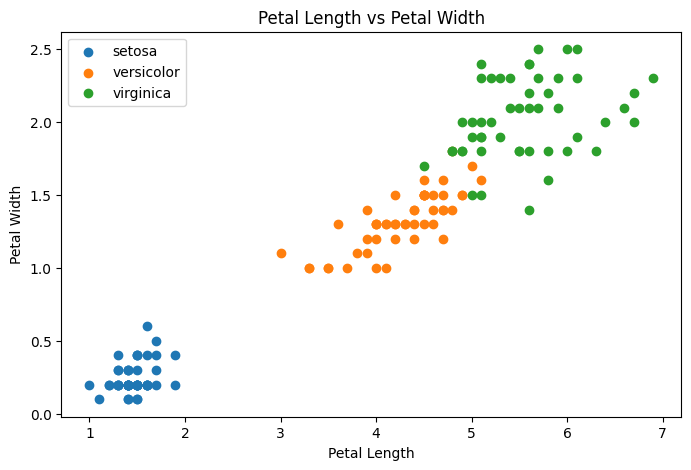

In [14]:
plt.figure(figsize=(8, 5))

for species in df["species"].unique():
    data = df[df["species"] == species]

    plt.scatter(
        data["petal_length"],
        data["petal_width"],
        label=species
    )

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()

plt.show()

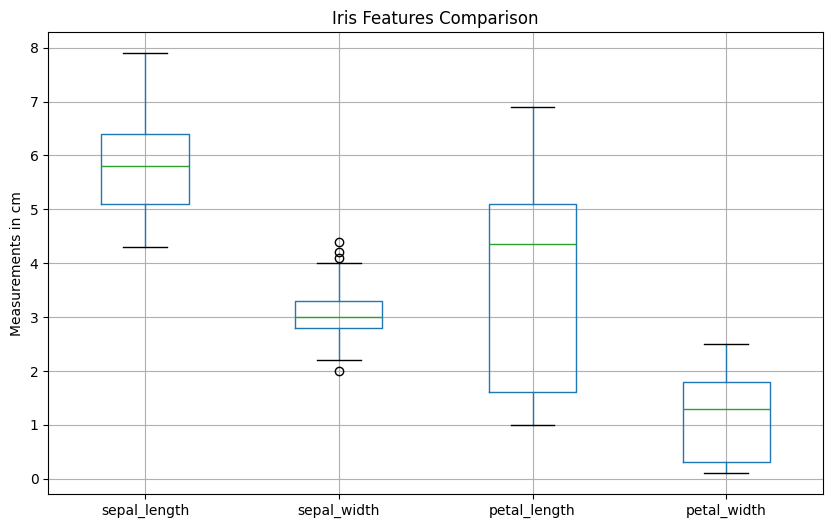

In [15]:
plt.figure(figsize=(10, 6))

df.boxplot(column=[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
])

plt.title("Iris Features Comparison")
plt.ylabel("Measurements in cm")

plt.show()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [17]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(url)

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nFeatures:", df.columns)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Shape: (150, 5)

Features: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [18]:
X = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]

y = df["species"]

print("Input Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

print("\nTarget Classes:")
print(y.unique())

Input Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target Variable:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

Target Classes:
['setosa' 'versicolor' 'virginica']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 120
Testing Records: 30


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("KNN Model Trained Successfully!")

KNN Model Trained Successfully!


In [22]:
y_pred = knn.predict(X_test_scaled)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']

Predicted Values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 93.33333333333333 %


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



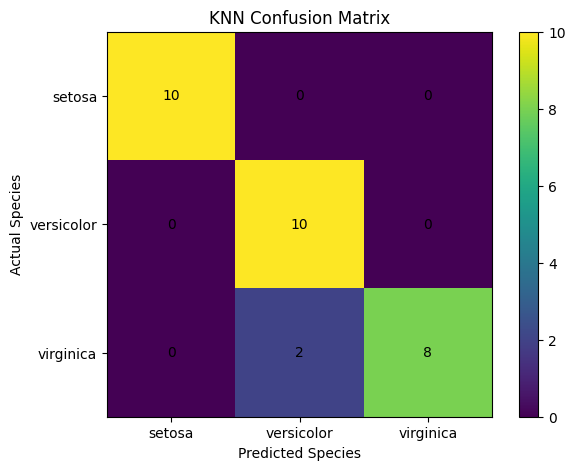

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1, 2], knn.classes_)
plt.yticks([0, 1, 2], knn.classes_)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("KNN Confusion Matrix")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [26]:
X_unsupervised = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]

print(X_unsupervised.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [27]:
scaler_unsupervised = StandardScaler()

X_scaled = scaler_unsupervised.fit_transform(X_unsupervised)

In [28]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("Cluster Assignments:")
print(clusters)

Cluster Assignments:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [29]:
df["Cluster"] = clusters

print(df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "Cluster"
]].head(10))

   sepal_length  sepal_width  petal_length  petal_width  Cluster
0           5.1          3.5           1.4          0.2        1
1           4.9          3.0           1.4          0.2        1
2           4.7          3.2           1.3          0.2        1
3           4.6          3.1           1.5          0.2        1
4           5.0          3.6           1.4          0.2        1
5           5.4          3.9           1.7          0.4        1
6           4.6          3.4           1.4          0.3        1
7           5.0          3.4           1.5          0.2        1
8           4.4          2.9           1.4          0.2        1
9           4.9          3.1           1.5          0.1        1


In [30]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518646


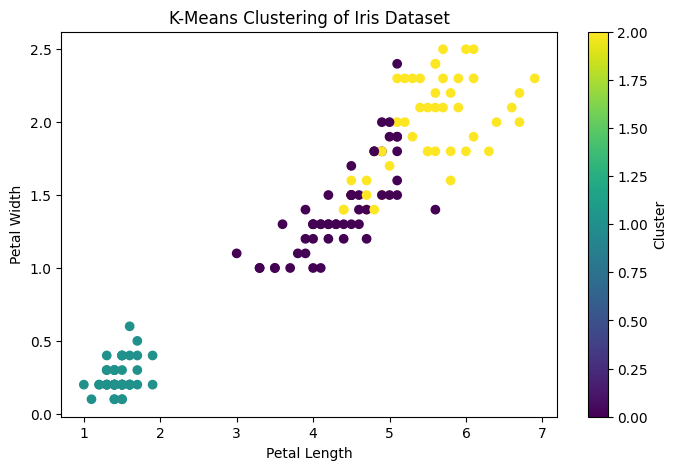

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["petal_length"],
    df["petal_width"],
    c=clusters
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering of Iris Dataset")
plt.colorbar(label="Cluster")

plt.show()

In [32]:
comparison = pd.crosstab(
    df["species"],
    df["Cluster"]
)

print(comparison)

Cluster      0   1   2
species               
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36


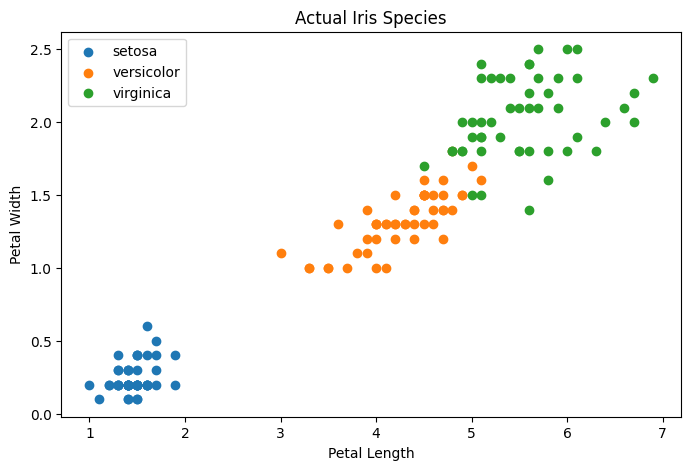

In [33]:
plt.figure(figsize=(8, 5))

for species in df["species"].unique():
    data = df[df["species"] == species]

    plt.scatter(
        data["petal_length"],
        data["petal_width"],
        label=species
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Actual Iris Species")
plt.legend()

plt.show()